# Building Markov Transition Matrix


## Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set plotting style
plt.style.use('ggplot')

## Load Sequence Data

We'll use the FASTA file from the assignment. If you're working with a different sequence file, just update the file path.

In [2]:
def read_fasta(file_path):
    """Read sequences from a FASTA file"""
    sequences = {}
    current_seq_id = None
    current_seq = []
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                # Save the previous sequence if there was one
                if current_seq_id is not None:
                    sequences[current_seq_id] = ''.join(current_seq)
                # Start a new sequence
                current_seq_id = line[1:]  # Remove the '>' character
                current_seq = []
            else:
                # Add to the current sequence
                current_seq.append(line)
    
    # Save the last sequence
    if current_seq_id is not None:
        sequences[current_seq_id] = ''.join(current_seq)
    
    return sequences

# Load sequences from file
file_path = 'multiline_input.fasta'
sequences = read_fasta(file_path)

# Print the loaded sequences
for seq_id, seq in sequences.items():
    print(f"Sequence ID: {seq_id}")
    print(f"Length: {len(seq)}")
    print(f"First 50 bases: {seq[:50]}...")
    print()

Sequence ID: 1
Length: 351
First 50 bases: TCCAATTGAGCTATACCGTCAGAAGTAGATGAGATCTAACGGCGCGCCCG...

Sequence ID: 2
Length: 332
First 50 bases: GATAGCGACGACGCTAGTTCCTAGGGACCCGGGGGGGATCAGTGGTGACG...

Sequence ID: 3
Length: 279
First 50 bases: GCCTATCTCACATGATAACCAGGTCTAGTTATGCTATTCATATACCTACT...

Sequence ID: 4
Length: 40
First 50 bases: GTAACCCTATAGTCAGGAGGTCACCCGTGATGTTAAGGCG...

Sequence ID: 5
Length: 257
First 50 bases: TTCCCGGATCAGTCACATCTAACATCTCATTGACTTCCTCCTATCGGTCG...

Sequence ID: 6
Length: 92
First 50 bases: GAAGTTGTAAAACTCAGACCATGTCATTAAGGTGCAATTGTAGTACAAAA...

Sequence ID: 7
Length: 206
First 50 bases: GAGGCCTTGGCGTGGAGGACACGGACTACCTTTAGTCGAAATTCCTACCA...

Sequence ID: 8
Length: 292
First 50 bases: CTCTTTCTGATACCTATAAATCTCAAACGGTAGGGTGATGTGACTAGCAA...

Sequence ID: 9
Length: 288
First 50 bases: ACGCCCAATAACTCGGTCGCACTGACCGAAAGTCGGTCACTTCTCGTAAT...

Sequence ID: 10
Length: 45
First 50 bases: ACAGAGCTCGCTGTAGTTTCCCGGCTTTCCCCAGCACCCGGCGCC...

Sequence ID: 11
Length: 310
First 50 

## Build the Markov Transition Matrix

For a first-order Markov model, we need to calculate the probability of transitioning from one nucleotide to another.

In [3]:
def build_transition_matrix(sequence):
    """Build a first-order Markov transition matrix from a sequence"""
    # Define the states (nucleotides)
    nucleotides = ['A', 'C', 'G', 'T']
    
    # Initialize count matrix with zeros
    count_matrix = {n1: {n2: 0 for n2 in nucleotides} for n1 in nucleotides}
    
    # Count transitions
    for i in range(len(sequence) - 1):
        current = sequence[i].upper()
        next_nuc = sequence[i + 1].upper()
        
        # Skip non-standard nucleotides
        if current not in nucleotides or next_nuc not in nucleotides:
            continue
            
        count_matrix[current][next_nuc] += 1
    
    # Convert counts to probabilities (normalize by row)
    prob_matrix = {n1: {} for n1 in nucleotides}
    for n1 in nucleotides:
        total = sum(count_matrix[n1].values())
        if total > 0:  # Avoid division by zero
            for n2 in nucleotides:
                prob_matrix[n1][n2] = count_matrix[n1][n2] / total
        else:
            # If no transitions from this nucleotide, set equal probabilities
            for n2 in nucleotides:
                prob_matrix[n1][n2] = 0.25
    
    return count_matrix, prob_matrix

## Apply the Model to Our Sequences

In [4]:
# Apply to the first sequence in our dataset
# If there are multiple sequences, we'll use the first one for demonstration
if sequences:
    sequence = list(sequences.values())[0]
    count_matrix, prob_matrix = build_transition_matrix(sequence)
    
    # Convert to DataFrames for better visualization
    count_df = pd.DataFrame(count_matrix)
    prob_df = pd.DataFrame(prob_matrix)
    
    print("Transition Count Matrix:")
    print(count_df)
    print("\nTransition Probability Matrix:")
    print(prob_df.round(4))
else:
    print("No sequences found in the file.")

Transition Count Matrix:
    A   C   G   T
A  26  28  13  27
C  19  24  27  19
G  29  19  14  19
T  20  17  27  22

Transition Probability Matrix:
        A       C       G       T
A  0.2766  0.3182  0.1605  0.3103
C  0.2021  0.2727  0.3333  0.2184
G  0.3085  0.2159  0.1728  0.2184
T  0.2128  0.1932  0.3333  0.2529


## Visualize the Transition Matrix

Heatmap visualization provides an intuitive way to understand the transition probabilities.

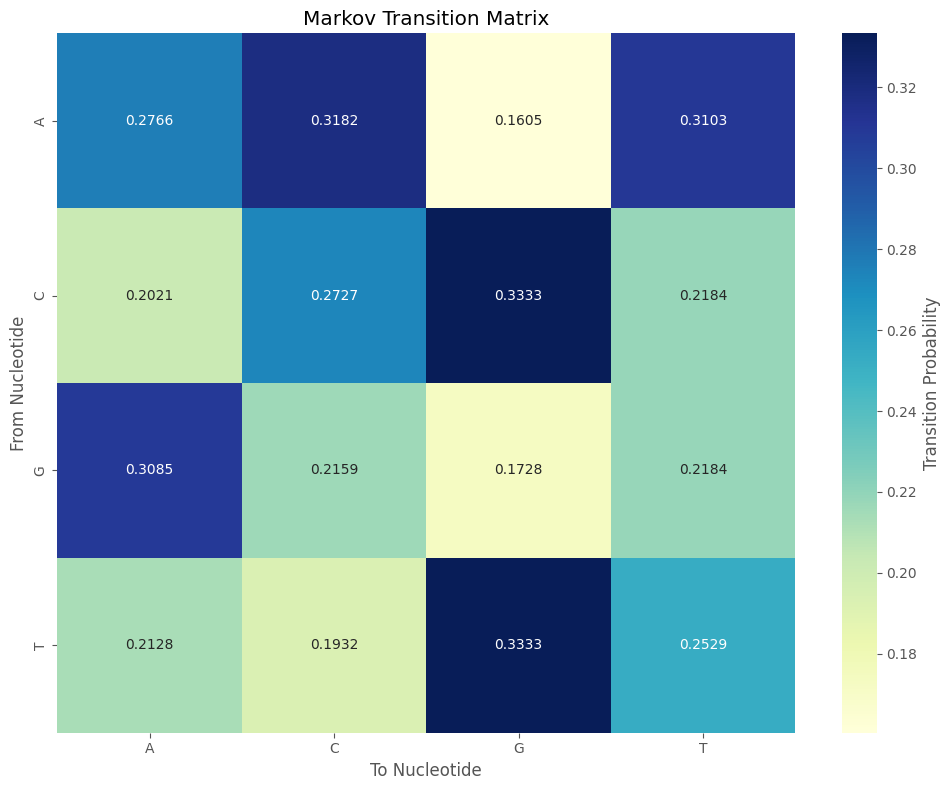

In [5]:
# Visualize the transition probability matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(prob_df, annot=True, cmap='YlGnBu', fmt='.4f', cbar_kws={'label': 'Transition Probability'})
plt.title('Markov Transition Matrix')
plt.xlabel('To Nucleotide')
plt.ylabel('From Nucleotide')
plt.tight_layout()
plt.show()

## Extend to All Sequences

Let's calculate the transition matrix for each sequence in our dataset.

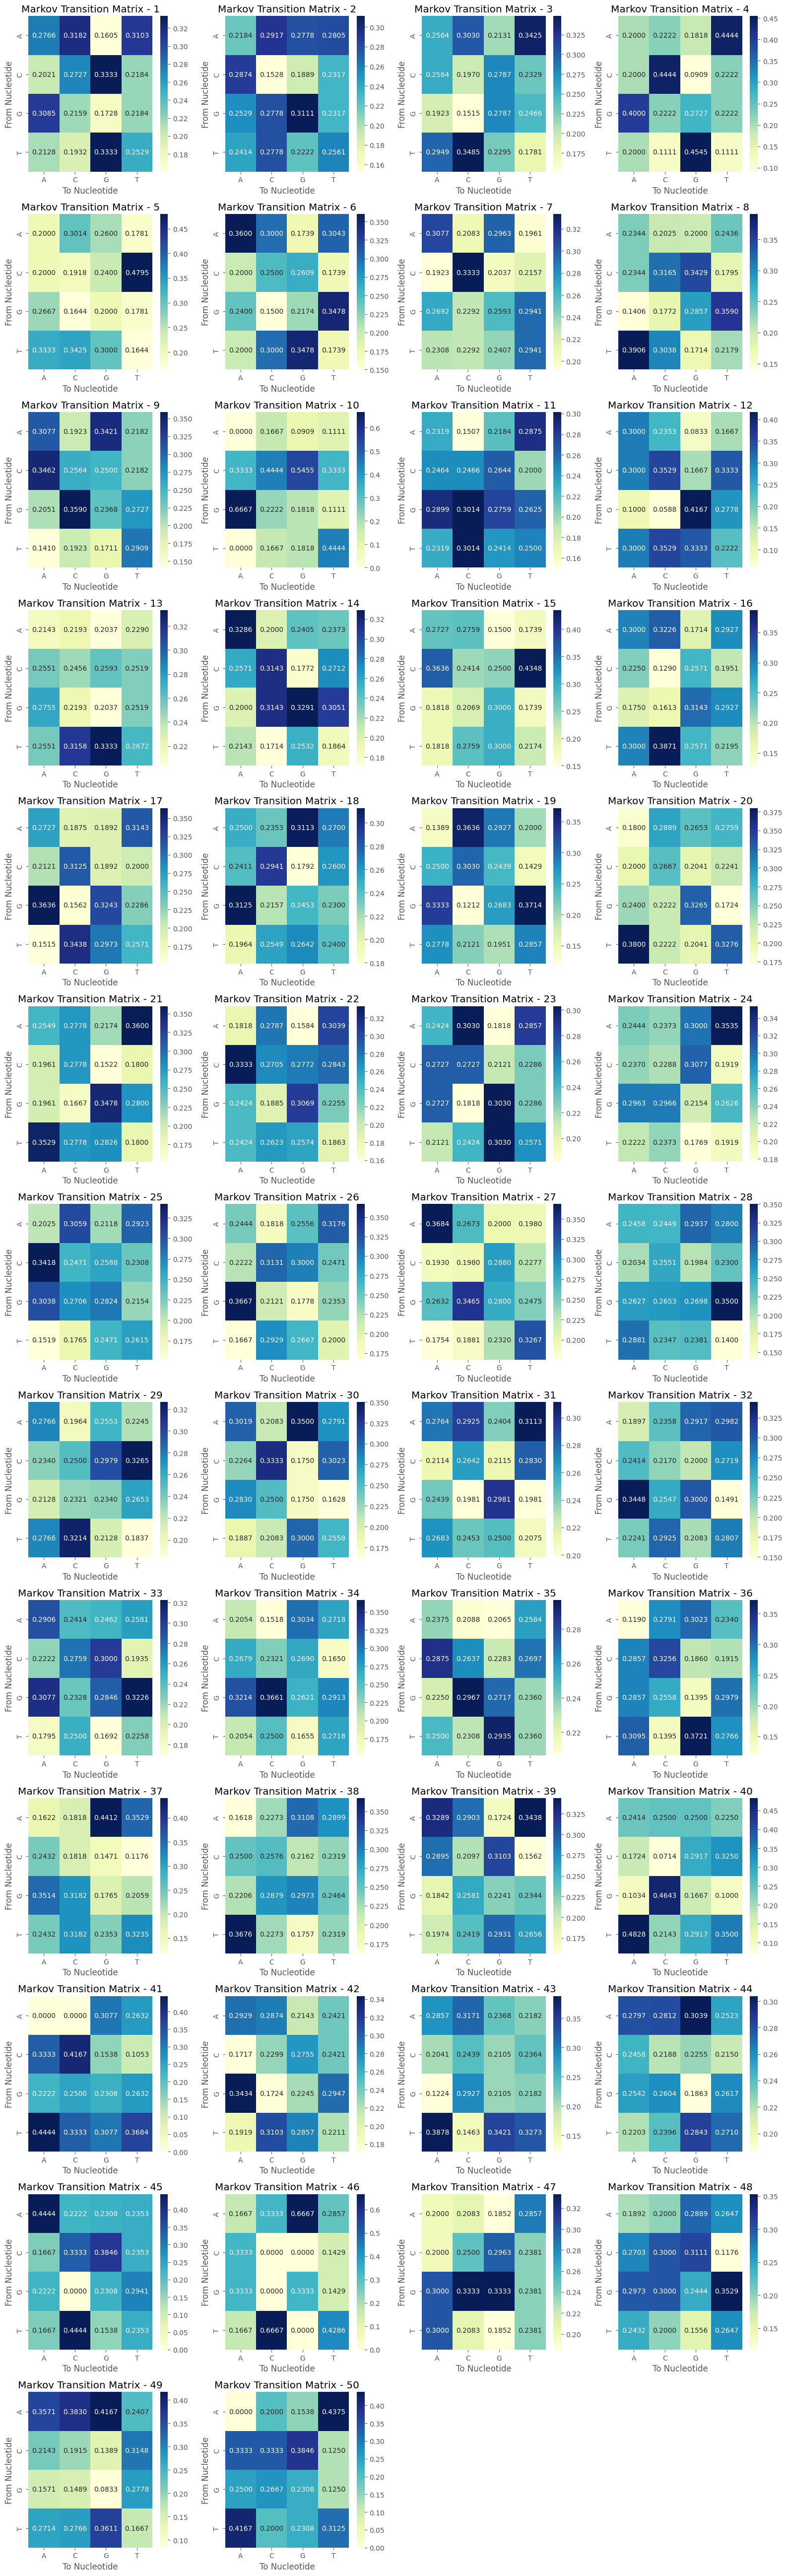

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set number of plots per row
plots_per_row = 4
total_sequences = len(sequences)
rows = (total_sequences + plots_per_row - 1) // plots_per_row

fig, axes = plt.subplots(rows, plots_per_row, figsize=(plots_per_row * 4, rows * 4))
axes = axes.flatten()  # Flatten to easily index even with 1 row

for i, (seq_id, sequence) in enumerate(sequences.items()):
    count_matrix, prob_matrix = build_transition_matrix(sequence)
    prob_df = pd.DataFrame(prob_matrix).round(4)
    
    ax = axes[i]
    sns.heatmap(prob_df, annot=True, cmap='YlGnBu', fmt='.4f', ax=ax)
    title = f'Markov Transition Matrix - {seq_id[:30]}...' if len(seq_id) > 30 else f'Markov Transition Matrix - {seq_id}'
    ax.set_title(title)
    ax.set_xlabel('To Nucleotide')
    ax.set_ylabel('From Nucleotide')

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
